# Titanic Passenger Survival Analysis
This notebook contains the complete Titanic passenger analysis assignmentusing Pandas, Matplotlib and Seaborn.

In [ ]:
# This project analyzes the Titanic passenger dataset to identify patterns in passenger demographics, travel characteristics, and survival outcomes. The analysis includes data cleaning, feature engineering, exploratory analysis, and visualization using Python.

In [ ]:
## Project Overview

### Dataset
- **Rows:** 891
- **Columns:** 12
- **Analysis Type:** Exploratory Data Analysis
- **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Key Areas of Analysis
- Passenger demographics
- Passenger class distribution
- Age and fare distribution
- Family size
- Survival patterns
- Relationships between numerical variables

## 1. Import Libraries and Load the Dataset

The Titanic dataset is loaded into a Pandas DataFrame. Matplotlib and Seaborn are used to create the required visualizations.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv(r'd:\Taanya\Downloads\Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Basic Data Exploration

First, check the structure of the dataset and get a statistical summary.

In [9]:
df.info()

print('\nSummary statistics:')
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Summary statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Check and Handle Missing Values

Age has missing values, so the missing ages are replaced with the median age. The two missing Embarked values are replaced with the mode. Cabin has many missing values, so it is not needed for the visualizations in this assignment.

In [10]:
print('Missing values before handling:')
print(df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print('\nMissing values after handling:')
print(df.isnull().sum())

Missing values before handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


## Create Family Size

Family size is calculated as `SibSp + Parch` as required in Q5.

In [11]:
df['Family_Size'] = df['SibSp'] + df['Parch']
df[['SibSp', 'Parch', 'Family_Size']].head()

,SibSp,Parch,Family_Size
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


## Countplot – Number of Passengers by Gender

This countplot shows how many male and female passengers were present in the Titanic dataset.

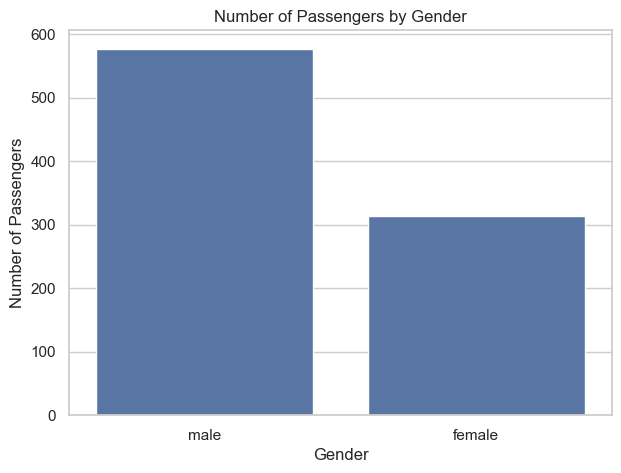

In [12]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Sex')
plt.title('Number of Passengers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()


**Interpretation:** The chart shows that there were more male passengers than female passengers in the dataset.

## Bar Chart – Number of Passengers in Each Passenger Class

This bar chart compares the number of passengers in Pclass 1, 2 and 3 using different colors.

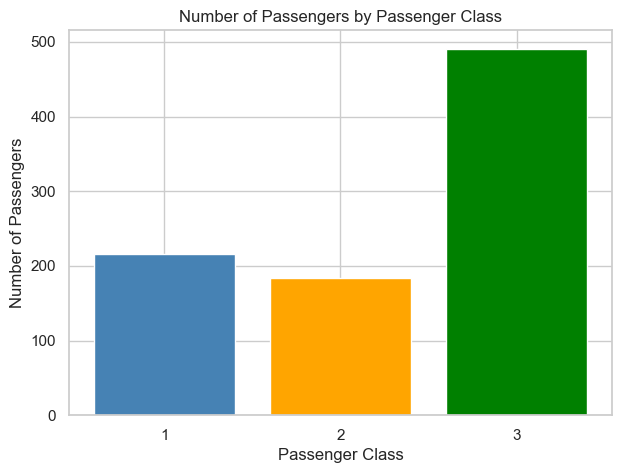

In [13]:
class_counts = df['Pclass'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    class_counts.index.astype(str),
    class_counts.values,
    color=['steelblue', 'orange', 'green']
)
plt.title('Number of Passengers by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()


**Interpretation:** The chart shows how passengers were distributed across the three passenger classes. Class 3 contains the largest number of passengers.

##  Histogram – Distribution of Passenger Age

A histogram is used to see how passenger ages are distributed.

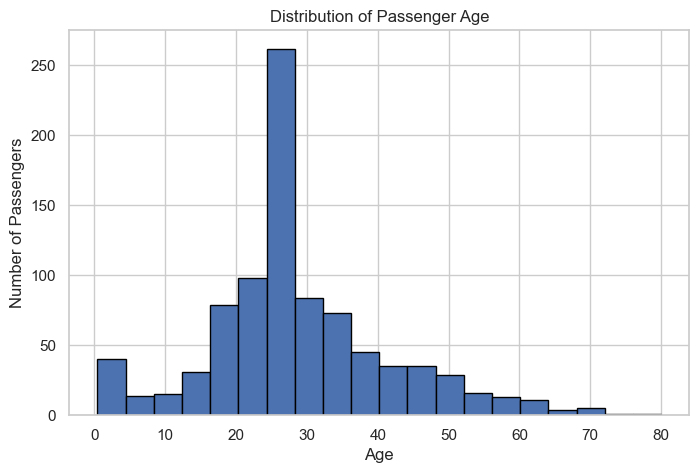

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()


**Interpretation:** Most passengers were young or middle-aged, while relatively fewer passengers were in the older age groups.

## Q4. Boxplot – Outliers in Fare

A boxplot is useful for identifying unusually high or low values in the Fare column.

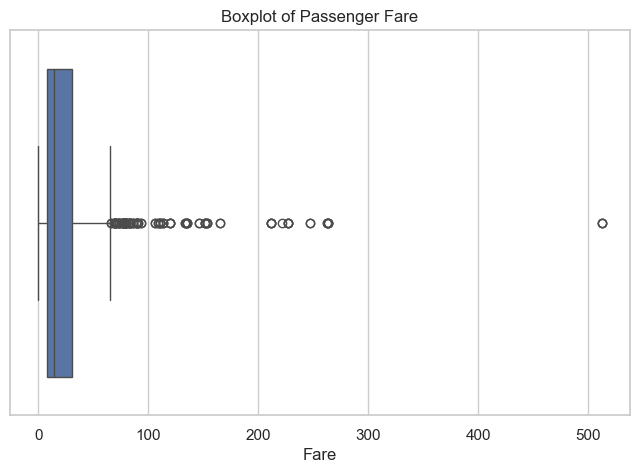

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Fare')
plt.title('Boxplot of Passenger Fare')
plt.xlabel('Fare')
plt.show()


**Interpretation:** The boxplot shows several high-fare observations. These are potential outliers compared with the majority of passenger fares.

##  Scatterplots – Age/Fare and Family Size/Fare

Two scatterplots are created: one for age versus fare and another for family size versus fare.

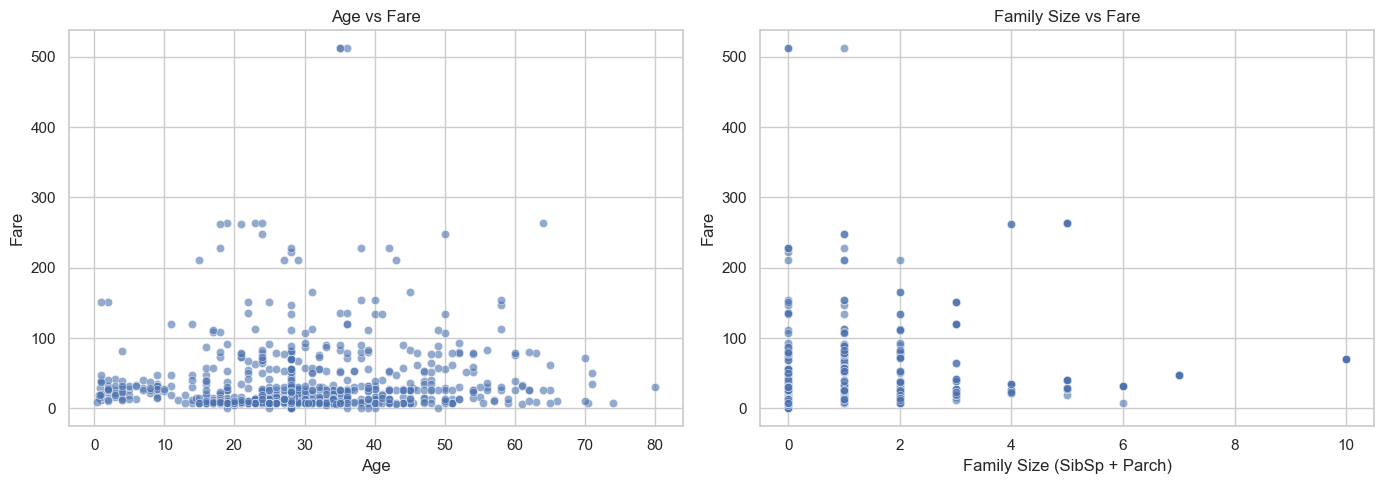

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='Age', y='Fare', ax=axes[0], alpha=0.6)
axes[0].set_title('Age vs Fare')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Fare')

sns.scatterplot(data=df, x='Family_Size', y='Fare', ax=axes[1], alpha=0.6)
axes[1].set_title('Family Size vs Fare')
axes[1].set_xlabel('Family Size (SibSp + Parch)')
axes[1].set_ylabel('Fare')

plt.tight_layout()
plt.show()


**Interpretation:** The Age vs Fare plot does not show a strong direct relationship between age and fare. The Family Size vs Fare plot also shows that fare varies widely for different family sizes, with some high-fare observations appearing among smaller and larger families.

## Countplot – Survival Count by Gender

This chart compares the number of survivors and non-survivors for male and female passengers.

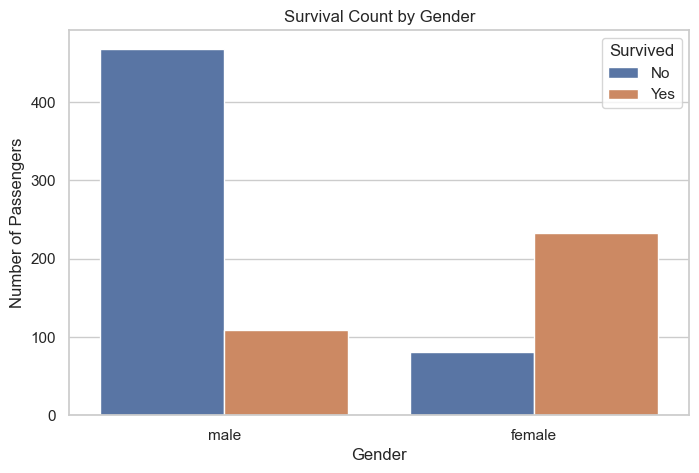

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()



**Interpretation:** Female passengers had a much higher survival count relative to their total number, while a large proportion of male passengers did not survive.

In [18]:
# Survival rate by gender
survival_by_gender = df.groupby('Sex')['Survived'].mean() * 100
survival_by_gender.round(2)

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

## Bar Chart – Survival by Passenger Class

This bar chart compares the number of survivors and non-survivors in each passenger class.

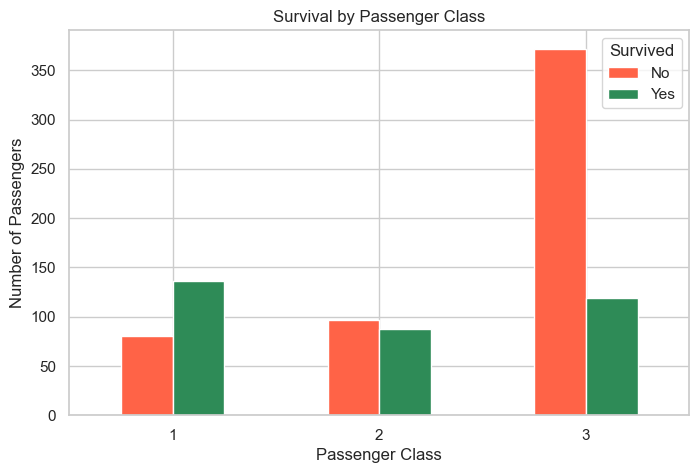

In [19]:
survival_class = pd.crosstab(df['Pclass'], df['Survived'])

survival_class.plot(
    kind='bar',
    figsize=(8, 5),
    color=['tomato', 'seagreen']
)

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()


**Interpretation:** Passenger class had a clear relationship with survival. First-class passengers had a much better chance of survival than third-class passengers.

In [20]:
# Survival rate by passenger class
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
survival_by_class.round(2)

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

##  Heatmap – Correlation Between Numerical Variables

A correlation heatmap shows how numerical variables are related to one another. Values closer to 1 or -1 indicate stronger relationships.

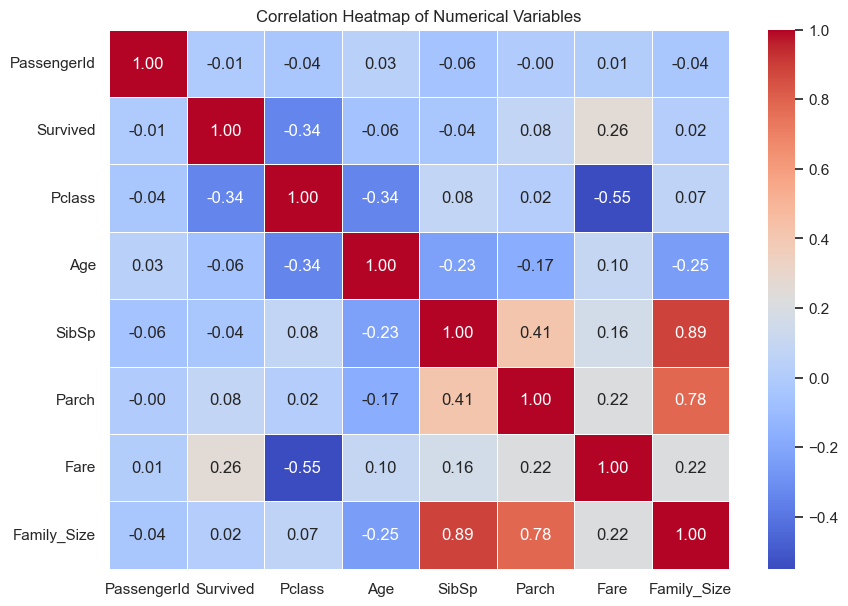

In [21]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()


**Interpretation:** The heatmap helps identify which numerical variables have stronger relationships. For example, Survived is related to Pclass, while SibSp and Parch provide information about family relationships.

##   passenger class who paid the highest fare on average

The average fare is calculated for each passenger class. The class with the highest mean fare paid the highest fare on average.

In [22]:
average_fare = df.groupby('Pclass')['Fare'].mean().sort_values(ascending=False)

print('Average fare by passenger class:')
display(average_fare)

highest_class = average_fare.idxmax()
highest_average = average_fare.max()

print('Passenger class with the highest average fare:', highest_class)
print('Highest average fare:', highest_average)


Average fare by passenger class:


Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

Passenger class with the highest average fare: 1
Highest average fare: 84.1546875


**Interpretation:** Passenger Class 1 paid the highest average fare, while Class 3 paid the lowest average fare.

##  Final Insights from the Dataset
Based on the visualizations, the following are the main observations from the Titanic dataset.

In [23]:
print('1. The dataset contains more male passengers than female passengers.')
print('2. Passenger Class 3 has the largest number of passengers.')
print('3. Most passengers were in the young to middle-age range.')
print('4. The Fare column contains several high-value outliers.')
print('5. Female passengers had a much higher survival rate than male passengers.')
print('6. First-class passengers had better survival outcomes than third-class passengers.')
print('7. First-class passengers also paid the highest average fare.')
print('8. Age and fare do not show a strong direct relationship.')
print('9. Family size and fare vary considerably, so family size alone does not explain fare.')
print('10. The correlation heatmap shows useful relationships among the numerical variables.')


1. The dataset contains more male passengers than female passengers.
2. Passenger Class 3 has the largest number of passengers.
3. Most passengers were in the young to middle-age range.
4. The Fare column contains several high-value outliers.
5. Female passengers had a much higher survival rate than male passengers.
6. First-class passengers had better survival outcomes than third-class passengers.
7. First-class passengers also paid the highest average fare.
8. Age and fare do not show a strong direct relationship.
9. Family size and fare vary considerably, so family size alone does not explain fare.
10. The correlation heatmap shows useful relationships among the numerical variables.


**Interpretation:** Overall, the visualizations show that gender and passenger class were important factors associated with survival. Fare also differed strongly between classes, while age and family size had less obvious direct relationships with fare.

## Conclusion

The Titanic dataset was explored using Pandas, Matplotlib and Seaborn. The analysis covered passenger distribution, age, fare outliers, family size, survival patterns, passenger class and correlations between numerical variables.